In [2]:
import pandas as pd

In [40]:
file_path = "/Users/vaishnavinibhanupudi/Downloads/loan_prediction/data/raw/Loan_Default 3.csv"
df_data = pd.read_csv(file_path)

df_data.head(20)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,...,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
7,24897,2019,NaN,Female,nopre,type1,p4,l1,nopc,nob/c,...,CIB,863,CIB,55-64,to_inst,86.525974,North,direct,0,42.0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,...,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
9,24899,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,...,CIB,788,EXP,55-64,to_inst,63.444767,south,direct,0,30.0


In [66]:
df_data.shape

(148670, 34)

The dataset contains 148,670 rows of data with 34 columns, including the target variable (default or not default)

In [67]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

Note, some columns are objects whereas others are numeric datatypes. The object columns will have to be encoded before applying ML models

In [44]:
df_data.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


Debt-to-income ratio (DTI) measures the percentage of your gross monthly income that goes toward paying debts. It compares your recurring debt obligations against your total earnings before taxes. This ratio is used by lenders to see if you can handle a new loan. A high DTI ratio may indicate that you currently have too much debt, so from a lender perspective, it is risky to give you a loan.

LTV ratio (Loan to value) is the amount you borrowed (loan amount) / the appraised value of the asset. A LTV ratio over 80% is typically viewed unfavorably

Status is the target variable. We are trying to predict whether or not the loan will default. A value of 0 for the loan_status target variable means the applicant defaulted (did not pay the loan). A value of 0 for the target variable means the applicant paid the loan back successfuly, and a value of 1 denotes a default

Looking at the summary statistics, we can see that not all columns have the same amount of rows, indicating missing values. This is something to explore further.

I also notice that the max LTV ratio is very high. This could be caused by a low property value. For example, the lowest property value we see is $8000. This is something to explore further later. 

I notice that the minimum value for interest_rate_spread is negative. This is okay, however, because interest_rate_spread represents how the interest_Rate compares to a benchmark interest rate. 

In [70]:
#analyzing summary statistics for categorical columns
categorical_cols = df_data.select_dtypes('object').columns
df_data[categorical_cols].describe()

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,Neg_ammortization,interest_only,...,construction_type,occupancy_type,Secured_by,total_units,credit_type,co-applicant_credit_type,age,submission_of_application,Region,Security_Type
count,145326,148670,147762,148670,148536,148670,148670,148670,148549,148670,...,148670,148670,148670,148670,148670,148670,148470,148470,148670,148670
unique,2,4,2,3,4,2,2,2,2,2,...,2,3,2,4,4,2,7,2,4,2
top,cf,Male,nopre,type1,p3,l1,nopc,nob/c,not_neg,not_int,...,sb,pr,home,1U,CIB,CIB,45-54,to_inst,North,direct
freq,135348,42346,124621,113173,55934,142344,148114,127908,133420,141560,...,148637,138201,148637,146480,48152,74392,34720,95814,74722,148637


In [71]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df_data[col].value_counts(dropna=False))


loan_limit
loan_limit
cf     135348
ncf      9978
NaN      3344
Name: count, dtype: int64

Gender
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64

approv_in_adv
approv_in_adv
nopre    124621
pre       23141
NaN         908
Name: count, dtype: int64

loan_type
loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

loan_purpose
loan_purpose
p3     55934
p4     54799
p1     34529
p2      3274
NaN      134
Name: count, dtype: int64

Credit_Worthiness
Credit_Worthiness
l1    142344
l2      6326
Name: count, dtype: int64

open_credit
open_credit
nopc    148114
opc        556
Name: count, dtype: int64

business_or_commercial
business_or_commercial
nob/c    127908
b/c       20762
Name: count, dtype: int64

Neg_ammortization
Neg_ammortization
not_neg    133420
neg_amm     15129
NaN           121
Name: count, dtype: int64

interest_only
interest_only
not_int     141560
int_

In [72]:
df_data.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [73]:
missing = (
    df_data.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)
print(missing)

Upfront_charges              26.66
Interest_rate_spread         24.64
rate_of_interest             24.51
dtir1                        16.22
LTV                          10.16
property_value               10.16
income                        6.15
loan_limit                    2.25
approv_in_adv                 0.61
submission_of_application     0.13
age                           0.13
loan_purpose                  0.09
Neg_ammortization             0.08
term                          0.03
Region                        0.00
total_units                   0.00
Security_Type                 0.00
Status                        0.00
co-applicant_credit_type      0.00
Credit_Score                  0.00
credit_type                   0.00
ID                            0.00
Secured_by                    0.00
occupancy_type                0.00
construction_type             0.00
year                          0.00
interest_only                 0.00
loan_amount                   0.00
business_or_commerci

Note, some columns have very small percentages of missing values, whereas other columns have much higher percentages of missing values. We will later have to consider how to approach dealing with these values

In [74]:
#analyzing break up of the target variable -- proportion of defaults and non-defaults
df_data["Status"].value_counts(normalize=True)

Status
0    0.753555
1    0.246445
Name: proportion, dtype: float64

75% of the dataset contains non-defaults (successfully repaid), while 25% of the dataset contains defaults. Therefore, this dataset could potentially reflect real world distributions, as defaults are rarer

In [76]:
df_data["Status"].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

array([[<Axes: title={'center': 'ID'}>, <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'rate_of_interest'}>],
       [<Axes: title={'center': 'Interest_rate_spread'}>,
        <Axes: title={'center': 'Upfront_charges'}>,
        <Axes: title={'center': 'term'}>,
        <Axes: title={'center': 'property_value'}>],
       [<Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'Credit_Score'}>,
        <Axes: title={'center': 'LTV'}>,
        <Axes: title={'center': 'Status'}>],
       [<Axes: title={'center': 'dtir1'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

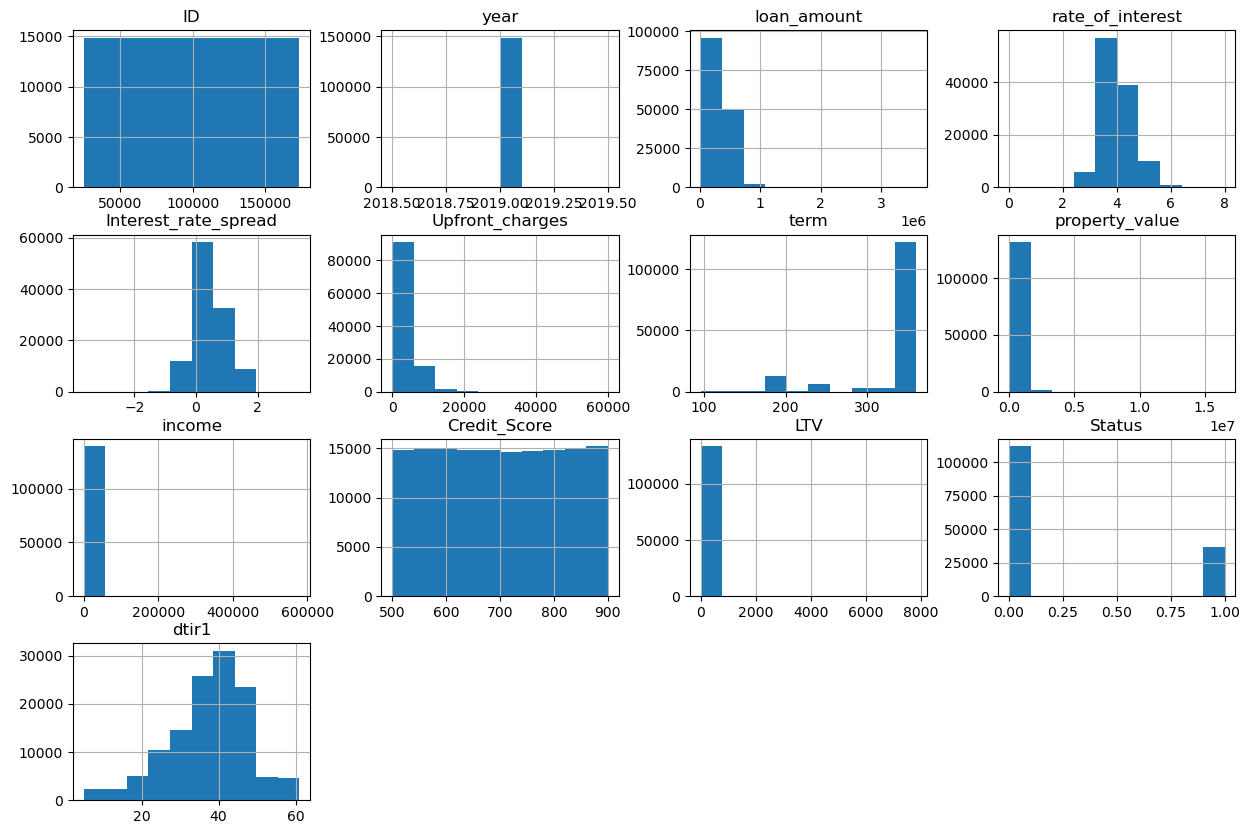

In [77]:
df_data.hist(figsize=(15, 10))

ID is a unique identifier of every applicant and therefore likely does not show a meaningful pattern. This feature will be dropped when preprocessing the data. 

The histogram for year is clustered around 2019 only, which is confirmed by the summary statistics we analyzed earlier that showed a min and max of 2019. This means our data is from 2019, and is unlikely to affect the target variable or show a meaningful pattern.

The histogram for loan amount appears to be right-skewed. Most of the loan amounts are clustered toward the left, so there are lots of small loans, with a few larger loans (creating the right tail)

The rate of interest appears to follow a bell-shaped curve, with most loans having an interest rate of 4% and few interest rates that are extremely high or low. This is reflected by the summary statistics where the 25%, 50%, and 75% quartiles are all approximately 4%.

Interest_rate_spread also appears to follow a bell-shaped curve, similar to rate_of_interest. This may be because interest_rate_spread is derived from the difference between the rate_of_interest and a comparison benchmark.

Upfront_charges appears to also be right-skewed, with most of the values clustered towards the left (so a higher number of lower upfront charges), with a few higher upfront charges.

Term seems to be left-skewed, with most values being higher terms.

Property value is right-skewed, with a few properties that are very high in value. Income is also right-skewed. 

The distribution for credit score seems to be uniform/even. There do not seem to be obvious clusters around a particular score range. This may be something to dig into further, as credit scores typically may cluster around a median range in real world settings.

LTV (Loan-to-Value) is also right-skewed. 

Status is our binary categorical variable, with values of either 0 (successfully repaid loan) or 1 (defaulted loan).

dtir1 (Debt-to-Income Ratio) appears to approximately follow a bell-shaped curve, with the mean around 40, with a slight left skew.

**Checking Credit Score to analyze its distribution to see if the distribution is actually uniform or if there are any peaks or clusters:**

In [79]:
df_data["Credit_Score"].describe()

count    148670.000000
mean        699.789103
std         115.875857
min         500.000000
25%         599.000000
50%         699.000000
75%         800.000000
max         900.000000
Name: Credit_Score, dtype: float64

In [80]:
df_data["Credit_Score"].value_counts(normalize=True)

Credit_Score
763    0.002791
867    0.002778
639    0.002765
581    0.002744
554    0.002738
         ...   
745    0.002220
573    0.002220
743    0.002200
748    0.002179
559    0.002159
Name: proportion, Length: 401, dtype: float64

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


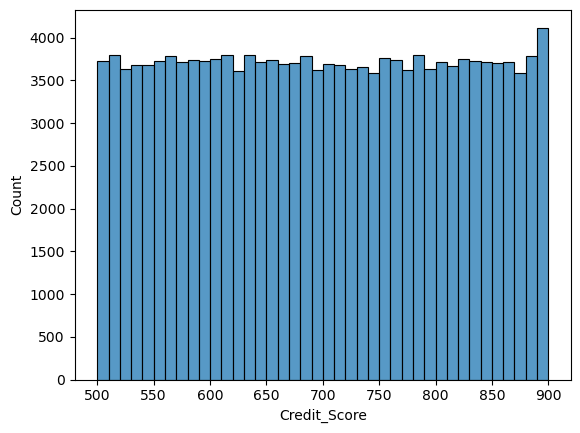

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_data["Credit_Score"], bins=40)

plt.show()

**Creating box plots for each numeric variable**

This allows us to identify potential outliers and understand the spread of the data

In [83]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

#defining the columns that are numeric:
numerical_cols = df_data.select_dtypes(include="number").columns
print(numerical_cols)

Index(['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')


In [87]:
n_cols = 3 #defining the number of columns we want in the output figure (number of boxplots per row)
n_rows = math.ceil(len(numerical_cols) / n_cols) 
'''determining the number of rows--distributing the total number of numerical columns across rows with 3 numerical columns per row of the boxplot outputs'''

'determining the number of rows--distributing the total number of numerical columns across rows with 3 numerical columns per row of the boxplot outputs'

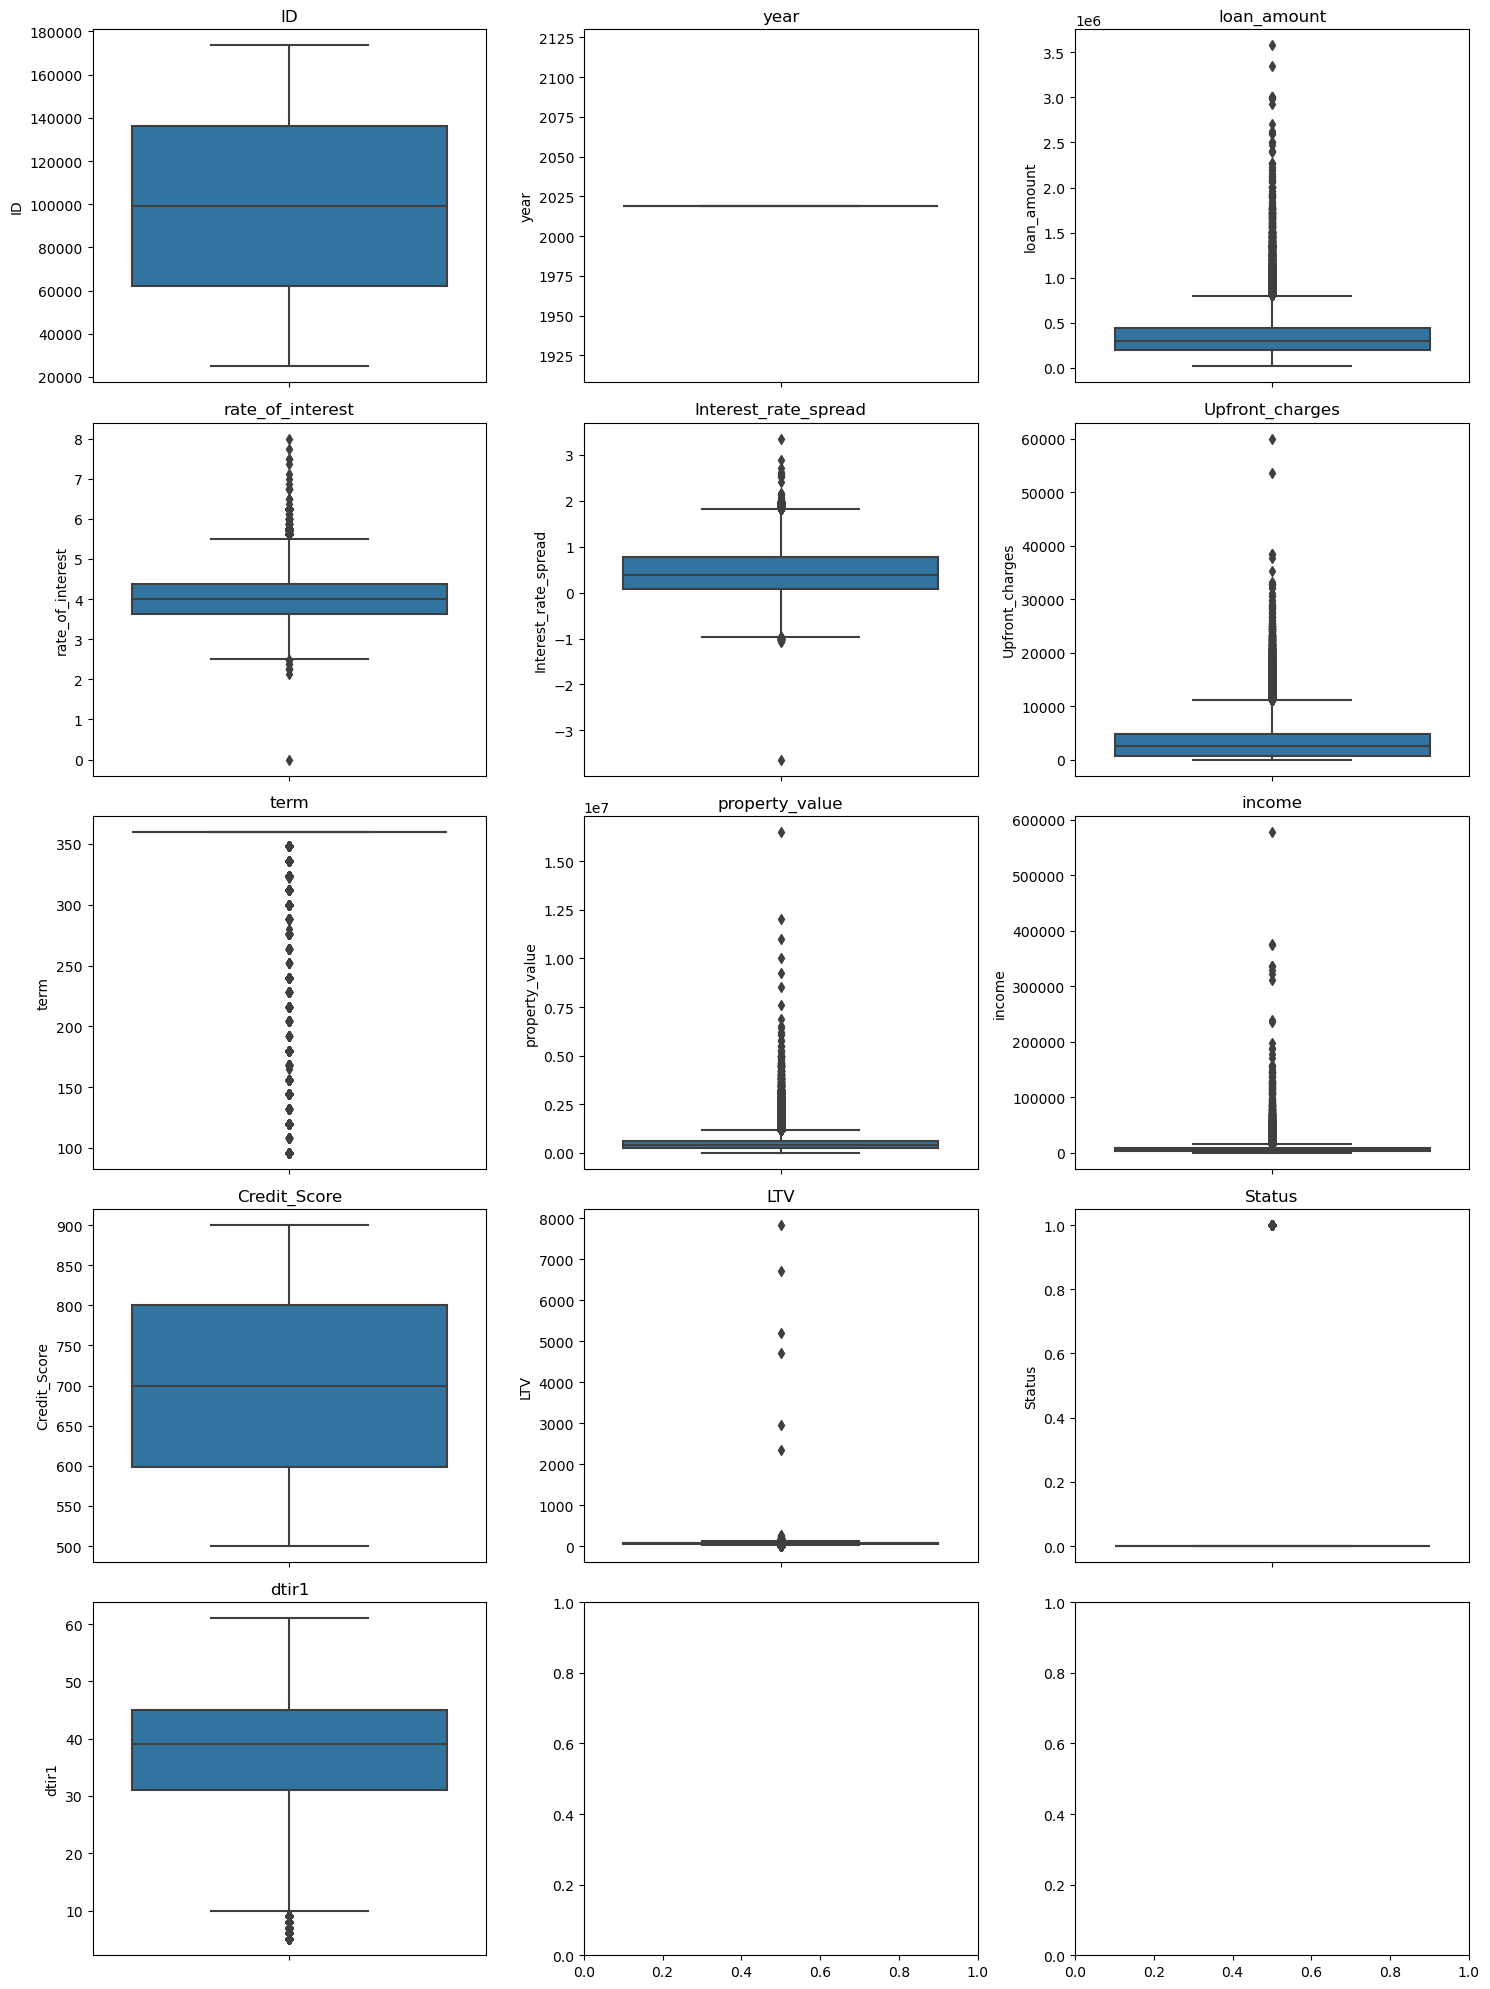

In [91]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows)) 
#fig returns the overall figure which contains all the plots, and axes is each of the graphs

axes = axes.flatten() #making the 2D numpy array into a 1D array so we can apply sns.boxplot and iterate through each subplot one at a time

for axis, col in zip(axes, numerical_cols):
    sns.boxplot(y=df_data[col], ax = axis)
    axis.set_title(col)

plt.tight_layout()
plt.show()



The boxplot for loan_amount verifies our findings from the histogram analysis. The median seems to be closer to the bottom of the box/IQR. The upper whisker is longer than the lower whisker, indicating there is more spread of data across upper quartile. There also seem to be a lot of outliers above the upper end of the range. 

The boxplot for the rate_of_interest variable is largely symmetric as well, but there are many outliers above the 75th percentile (marked by the upper whisker) compared to a few below the 25th percentile. 

Likewise, the boxplot for interest_rate_spread is approximately symmetric, with more upper outliers. 

The boxplot for upfront_charges shows that the median seems to be closer to the bottom of the plot, and the upper tail is longer. There are also more outliers above the upper tail. This matches the right-skew we saw in the histogram.

Property_value seems to show a strong right skew as well, with a small IQR that is closer to the bottom of the plot. This matches the findings in the histogram, where most of the property_values are clustered around lower values. However, there are several outliers, above the upper whisker. 

Income shows similar findings, with a strong right skew, small IQR, and several outliers above the upper whisker.

Credit_score shows a symmetric box plot, and the spread of the upper and lower ends of the range are even. This matches the findings from the histogram, where I found that credit score seems to be uniformly distributed, without clusters around any particular credit score range. 

Loan-to-value seems to have a small IQR and shows a strong right-skew (as did the histogram), with several outliers above the upper whisker. The highest outlier seems to represent a LTV ratio of about 8000%, which is something to investigate, as it much higher than the typical LTV ratio. 


Investigating loan amounts outliers:

In [98]:
df_data.nlargest(10, "loan_amount")[["loan_amount", "rate_of_interest", "Upfront_charges", "Interest_rate_spread", "property_value", "LTV"]]

,loan_amount,rate_of_interest,Upfront_charges,Interest_rate_spread,property_value,LTV
4321,3576500,NaN,NaN,NaN,5208000.0,68.673195
98146,3346500,NaN,NaN,NaN,NaN,NaN
3762,3006500,3.990,60000.00,0.5414,5258000.0,57.179536
54519,3006500,3.125,0.00,-0.3637,5758000.0,52.214311
86408,3006500,NaN,NaN,NaN,3508000.0,85.704105
121640,3006500,NaN,NaN,NaN,NaN,NaN
114333,2986500,3.990,12328.84,-0.2733,5508000.0,54.221133
42200,2926500,NaN,NaN,NaN,4878000.0,59.993850
68421,2706500,NaN,NaN,NaN,4508000.0,60.037711
128145,2626500,NaN,NaN,NaN,NaN,NaN


Although there are outliers significantly higher than the mean loan_amount, these observations also seem to be high-value properties. Additionally, looking at the LTV ratios for some of these observations, they seem to be within a typical range for a mortgage (about 50-70%), suggesting that these are not indications of issues with data quality and are instead likely to be a consequence of financing higher value properties. 

Investigating upfront charges outliers:

In [102]:
df_data.nlargest(20, "Upfront_charges")[["Upfront_charges", "loan_amount", "property_value"]]

,Upfront_charges,loan_amount,property_value
3762,60000.00,3006500,5258000.0
27166,53485.78,1306500,1708000.0
30636,38437.50,1756500,2508000.0
113641,38375.00,1356500,1858000.0
55892,37604.38,1716500,2398000.0
146563,35192.50,1276500,1728000.0
116695,33268.00,856500,1128000.0
136008,32850.00,1096500,1328000.0
125142,32825.25,746500,1298000.0
140825,32647.00,886500,1128000.0


Inspection of the observations with the largest upfront charges shows that these loans are also associated with relatively large loan amounts and property values. This suggests that the high upfront charges may be a consequence of financing larger, higher-valued properties rather than data quality issues.

Investigating the high LTV ratio outliers:

In [92]:
df_data.nlargest(10, "LTV")[["loan_amount", "property_value", "LTV"]]

,loan_amount,property_value,LTV
16951,626500,8000.0,7831.250000
55286,536500,8000.0,6706.250000
47807,416500,8000.0,5206.250000
65238,376500,8000.0,4706.250000
46287,236500,8000.0,2956.250000
123343,186500,8000.0,2331.250000
43348,126500,48000.0,263.541667
27473,66500,28000.0,237.500000
30837,66500,28000.0,237.500000
136154,546500,248000.0,220.362903


The observations with the highest LTV values are associated with unusually low property values relative to their loan amounts, resulting in very high LTV ratios, with the highest exceeding 2,000–7,800%. These values are substantially higher than typical mortgage LTV ratios and may indicate data quality issues or misrecorded property values. These observations should be investigated further before deciding whether to remove them from the dataset.

The property_values associated with the highest LTV values also seem to be much lower than the mean property value (around 497,893.5), with loan amounts higher than the mean loan_amount (331,117.7). This discrepancy explains the inflated Loan-to-Value ratio. 

**Analyzing correlations**

Correlation heatmap for numerical variables

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


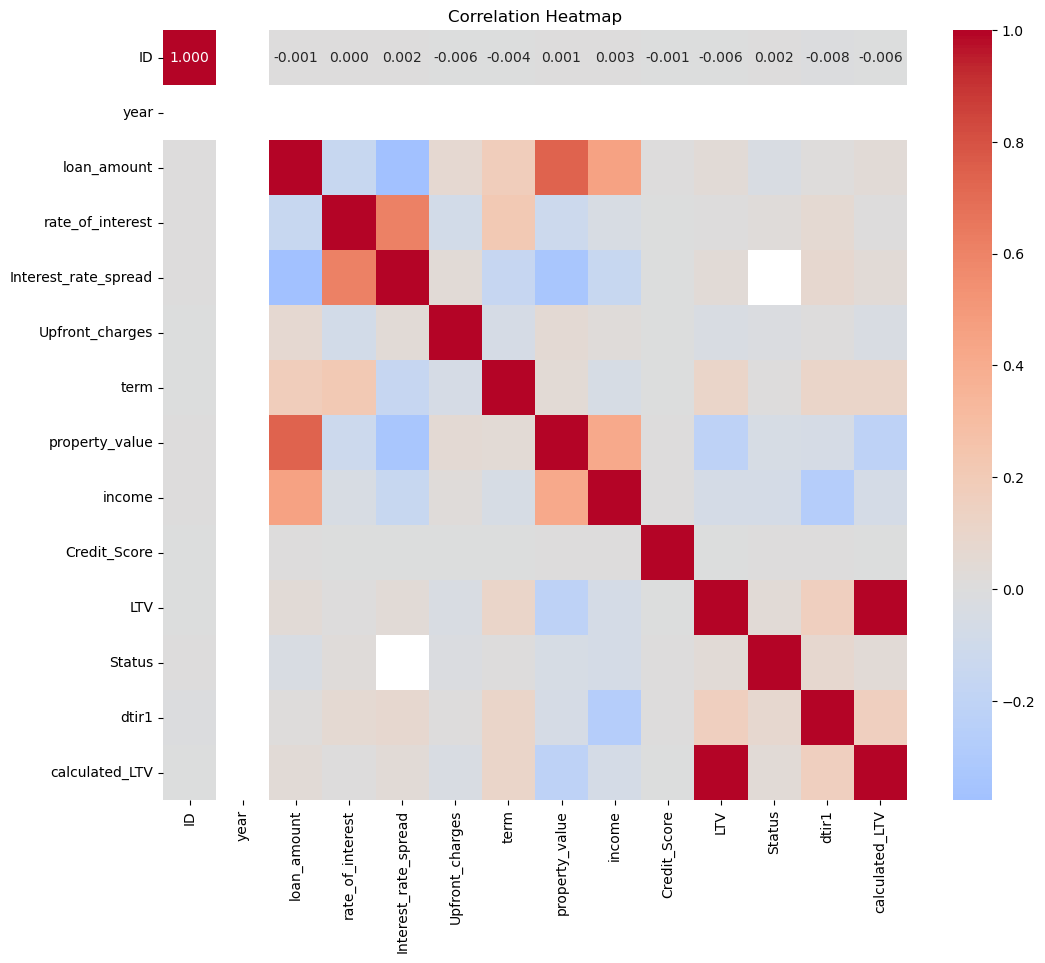

In [103]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f"
)

plt.title("Correlation Heatmap")
plt.show()